# Pandas - Full Guide

<svg viewBox="0 0 700 260" xmlns="http://www.w3.org/2000/svg" style="max-width:100%;height:auto;">
<rect width="700" height="260" rx="12" fill="#0d1117"/>
<text x="350" y="30" text-anchor="middle" fill="#e6edf3" font-family="sans-serif" font-size="17" font-weight="bold">Notebook Roadmap (teaching order)</text>
<g font-family="sans-serif" font-size="12" fill="#0d1117">
  <rect x="30"  y="60" width="180" height="150" rx="10" fill="#f9a825"/>
  <text x="120" y="85" text-anchor="middle" font-weight="bold">1. Pandas</text>
  <text x="120" y="105" text-anchor="middle">Series / DataFrame</text>
  <text x="120" y="122" text-anchor="middle">clean &amp; filter</text>
  <text x="120" y="139" text-anchor="middle">groupby</text>
  <text x="120" y="156" text-anchor="middle">merge / pivot</text>
  <text x="120" y="173" text-anchor="middle">time series</text>

  <rect x="260" y="60" width="180" height="150" rx="10" fill="#39c5cf"/>
  <text x="350" y="85" text-anchor="middle" font-weight="bold">2. NumPy</text>
  <text x="350" y="105" text-anchor="middle">arrays</text>
  <text x="350" y="122" text-anchor="middle">vectorization</text>
  <text x="350" y="139" text-anchor="middle">broadcasting</text>
  <text x="350" y="156" text-anchor="middle">linear algebra</text>
  <text x="350" y="173" text-anchor="middle">random / stats</text>

  <rect x="490" y="60" width="180" height="150" rx="10" fill="#66bb6a"/>
  <text x="580" y="85" text-anchor="middle" font-weight="bold">3. Visualization</text>
  <text x="580" y="105" text-anchor="middle">line / bar / hist</text>
  <text x="580" y="122" text-anchor="middle">scatter / box</text>
  <text x="580" y="139" text-anchor="middle">heatmap / pair</text>
  <text x="580" y="156" text-anchor="middle">facet / dashboards</text>
  <text x="580" y="173" text-anchor="middle">annotations</text>
</g>
<g stroke="#e6edf3" stroke-width="2" fill="none" marker-end="url(#arrow)">
  <line x1="210" y1="135" x2="258" y2="135"/>
  <line x1="440" y1="135" x2="488" y2="135"/>
</g>
<defs>
  <marker id="arrow" markerWidth="10" markerHeight="10" refX="6" refY="3" orient="auto">
    <path d="M0,0 L6,3 L0,6 z" fill="#e6edf3"/>
  </marker>
</defs>
<text x="350" y="240" text-anchor="middle" fill="#8b949e" font-family="sans-serif" font-size="12">Pandas first because it's the most immediately useful — NumPy and Matplotlib explain the "engine" underneath.</text>
</svg>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("numpy   :", np.__version__)
print("pandas  :", pd.__version__)
print("All libraries ready ✅")


: 

---
# Pandas

We start here because Pandas is what you'll touch first in almost any real job: loading a CSV, cleaning it up,
filtering it, summarizing it. It reads almost like plain English once you know the vocabulary.


## 1.1 — Series, DataFrames & first look at data

### Why does Pandas exist?
Real-world data almost never looks like a clean grid of pure numbers. It usually has:

- **Labels** — column names like `"age"` or `"salary"`, and row labels (an index), not just positions.
- **Mixed types** — text, numbers, dates, booleans, all in the same table.
- **Missing values** — gaps in the data (this is where `np.nan` comes in — it's just Pandas/NumPy's way
  of writing "no value here").

Pandas gives us two building blocks:

| Structure | Dimensions | Think of it as |
|---|---|---|
| **`Series`** | 1-D | A single labelled column — like one column of a spreadsheet |
| **`DataFrame`** | 2-D | A full table — literally a dictionary of `Series` sharing the same row index |


<svg viewBox="0 0 680 240" xmlns="http://www.w3.org/2000/svg" style="max-width:100%;height:auto;">
<rect width="680" height="240" rx="12" fill="#0d1117"/>
<text x="340" y="28" text-anchor="middle" fill="#e6edf3" font-family="sans-serif" font-size="16" font-weight="bold">Series (1-D) vs DataFrame (2-D)</text>
<text x="140" y="55" text-anchor="middle" fill="#8b949e" font-family="sans-serif" font-size="13">Series — one labelled column</text>
<g font-family="monospace" font-size="13" fill="#e6edf3"><rect x="60" y="65" width="60" height="30" fill="#0d3b42" stroke="#39c5cf"/><text x="90" y="85" text-anchor="middle">Amit</text><rect x="120" y="65" width="60" height="30" fill="#21262d" stroke="#39c5cf"/><text x="150" y="85" text-anchor="middle">85</text><rect x="60" y="95" width="60" height="30" fill="#0d3b42" stroke="#39c5cf"/><text x="90" y="115" text-anchor="middle">Sara</text><rect x="120" y="95" width="60" height="30" fill="#21262d" stroke="#39c5cf"/><text x="150" y="115" text-anchor="middle">92</text></g><text x="90" y="140" text-anchor="middle" fill="#8b949e" font-family="sans-serif" font-size="11">index</text><text x="150" y="140" text-anchor="middle" fill="#8b949e" font-family="sans-serif" font-size="11">values</text><text x="500" y="55" text-anchor="middle" fill="#8b949e" font-family="sans-serif" font-size="13">DataFrame — many labelled columns</text><g font-family="monospace" font-size="12" fill="#e6edf3"><rect x="400" y="65" width="50" height="26" fill="#f9a825" opacity="0.3" stroke="#f9a825"/><text x="425" y="83" text-anchor="middle">name</text><rect x="450" y="65" width="50" height="26" fill="#f9a825" opacity="0.3" stroke="#f9a825"/><text x="475" y="83" text-anchor="middle">age</text><rect x="500" y="65" width="60" height="26" fill="#f9a825" opacity="0.3" stroke="#f9a825"/><text x="530" y="83" text-anchor="middle">marks</text><rect x="400" y="91" width="50" height="26" fill="#21262d" stroke="#39c5cf"/><text x="425" y="109" text-anchor="middle">Amit</text><rect x="450" y="91" width="50" height="26" fill="#21262d" stroke="#39c5cf"/><text x="475" y="109" text-anchor="middle">21</text><rect x="500" y="91" width="60" height="26" fill="#21262d" stroke="#39c5cf"/><text x="530" y="109" text-anchor="middle">85</text><rect x="400" y="117" width="50" height="26" fill="#21262d" stroke="#39c5cf"/><text x="425" y="135" text-anchor="middle">Sara</text><rect x="450" y="117" width="50" height="26" fill="#21262d" stroke="#39c5cf"/><text x="475" y="135" text-anchor="middle">25</text><rect x="500" y="117" width="60" height="26" fill="#21262d" stroke="#39c5cf"/><text x="530" y="135" text-anchor="middle">92</text></g><text x="480" y="160" text-anchor="middle" fill="#8b949e" font-family="sans-serif" font-size="11">a DataFrame is really a dict of Series sharing one index</text></svg>

In [2]:
# A Series - one labelled 1-D column
marks = pd.Series([85, 92, 78], index=["Amit", "Sara", "Ravi"])
print(marks)
print("\nSara's marks:", marks["Sara"])
print("mean marks  :", marks.mean())


Amit    85
Sara    92
Ravi    78
dtype: int64

Sara's marks: 92
mean marks  : 85.0


### The Index — Pandas' most underrated idea
Every `Series` and `DataFrame` has an **Index**: labels attached to each row. 

It's not just a row number —
Pandas uses it for fast label-based lookup, and for **automatic alignment**: when you combine two Series,
Pandas matches rows by label first, not by position. This is why the example below produces a missing
value (`NaN` - Not a Number) for "Amit" — there's no "Amit" label in `bonus` to line up with.

In [3]:
bonus = pd.Series([5, 10], index=["Sara", "Ravi"])   # no "Amit" here, different order too
print("marks + bonus (aligned by LABEL, not position):\n", marks + bonus)
# NaN for Amit -- pandas did NOT just add position 0 to position 0.


marks + bonus (aligned by LABEL, not position):
 Amit     NaN
Ravi    88.0
Sara    97.0
dtype: float64


<div style="background:#0b1e2d;color:#e6edf3;border:1px solid #39c5cf;border-left:6px solid #39c5cf;border-radius:8px;padding:14px 16px;">
<b>🔑 Key theory takeaway</b>
<div style="margin-top:8px;">A plain list only knows positions (0, 1, 2, ...). A Pandas Series/DataFrame knows <b>labels</b>, and every operation between two of them tries to align by label first. Keep this in mind — it explains a lot of Pandas' behavior later on.</div>
</div>

### Creating a DataFrame
The most common way: a **dictionary** where keys become column names.

In [4]:
df = pd.DataFrame({
    "name":  ["Amit", "Sara", "Ravi", "Neha", "Karan"],
    "age":   [21, 25, 23, 22, 24],
    "city":  ["Pune", "Delhi", "Mumbai", "Pune", "Delhi"],
    "marks": [85, 92, 78, 88, 95]
})
df


,name,age,city,marks
0,Amit,21,Pune,85
1,Sara,25,Delhi,92
2,Ravi,23,Mumbai,78
3,Neha,22,Pune,88
4,Karan,24,Delhi,95


### Inspecting a DataFrame — what each command actually tells you
Always do this *first*, before writing a single line of analysis:

| Command | What it reveals |
|---|---|
| `df.shape` | row count and column count |
| `df.dtypes` / `df.info()` | is each column the type it should be? |
| `df.head()` / `df.tail()` | quick visual sanity check |
| `df.describe()` | count, mean, std, min, quartiles, max — numeric columns only |
| `df.isnull().sum()` | how much data is missing, per column |


In [5]:
print("shape   :", df.shape)          # (rows, columns)
print("columns :", list(df.columns))
print("dtypes  :\n", df.dtypes)

print("\n--- head(3) : first 3 rows ---")
print(df.head(3))

print("\n--- tail(2) : last 2 rows ---")
print(df.tail(2))

print("\n--- info() : types + non-null counts ---")
df.info()

print("\n--- describe() : summary statistics for numeric columns ---")
print(df.describe())


shape   : (5, 4)
columns : ['name', 'age', 'city', 'marks']
dtypes  :
 name       str
age      int64
city       str
marks    int64
dtype: object

--- head(3) : first 3 rows ---
   name  age    city  marks
0  Amit   21    Pune     85
1  Sara   25   Delhi     92
2  Ravi   23  Mumbai     78

--- tail(2) : last 2 rows ---
    name  age   city  marks
3   Neha   22   Pune     88
4  Karan   24  Delhi     95

--- info() : types + non-null counts ---
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    5 non-null      str  
 1   age     5 non-null      int64
 2   city    5 non-null      str  
 3   marks   5 non-null      int64
dtypes: int64(2), str(2)
memory usage: 292.0 bytes

--- describe() : summary statistics for numeric columns ---
             age      marks
count   5.000000   5.000000
mean   23.000000  87.600000
std     1.581139   6.580274
min    21.000000  78.000000
25%

### Selecting columns & rows
- Column → `df["col"]` (a Series) or `df[["a","b"]]` (a DataFrame with those columns)
- Row by **label** → `df.loc[...]`  •  Row by **position** → `df.iloc[...]`

**Why two accessors?** Row *labels* stay attached to their original rows even after sorting/filtering, while *positions* shift. `.loc`/`.iloc` force you to be explicit about which one you mean.

In [6]:
print("single column (Series):\n", df["name"])
print("\ntwo columns (DataFrame):\n", df[["name", "marks"]])

print("\nrow by label, df.loc[0]:\n", df.loc[0])
print("\nrow by position, df.iloc[-1]:\n", df.iloc[-1])         # last row
print("\nspecific cell, df.loc[0, 'name']:", df.loc[0, "name"])
print("rows 1-3, columns name & city:\n", df.loc[1:3, ["name", "city"]])


single column (Series):
 0     Amit
1     Sara
2     Ravi
3     Neha
4    Karan
Name: name, dtype: str

two columns (DataFrame):
     name  marks
0   Amit     85
1   Sara     92
2   Ravi     78
3   Neha     88
4  Karan     95

row by label, df.loc[0]:
 name     Amit
age        21
city     Pune
marks      85
Name: 0, dtype: object

row by position, df.iloc[-1]:
 name     Karan
age         24
city     Delhi
marks       95
Name: 4, dtype: object

specific cell, df.loc[0, 'name']: Amit
rows 1-3, columns name & city:
    name    city
1  Sara   Delhi
2  Ravi  Mumbai
3  Neha    Pune


## 1.2 — Filtering, cleaning & groupby

### Filtering — how boolean indexing actually works
`df[df["marks"] > 85]` looks like magic the first time you see it, but it's really two steps:
1. `df["marks"] > 85` produces a **boolean Series** the same length as `df`.
2. `df[...]` with that boolean Series keeps only the rows where it's `True`.


In [8]:
print("marks > 85:\n", df[df["marks"] > 85])

print("\nfrom Pune:\n", df[df["city"] == "Pune"])

# Combine conditions: & = AND, | = OR -- wrap EACH condition in parentheses
print("\nPune AND marks > 85:\n", df[(df["city"] == "Pune") & (df["marks"] > 85)])

# .isin() -- check membership in a list, cleaner than chaining many ORs
print("\nfrom Pune or Delhi:\n", df[df["city"].isin(["Pune", "Delhi"])])

# .query() -- write the condition as a readable string
print("\nusing .query():\n", df.query("marks > 80 and city == 'Delhi'"))


marks > 85:
     name  age   city  marks
1   Sara   25  Delhi     92
3   Neha   22   Pune     88
4  Karan   24  Delhi     95

from Pune:
    name  age  city  marks
0  Amit   21  Pune     85
3  Neha   22  Pune     88

Pune AND marks > 85:
    name  age  city  marks
3  Neha   22  Pune     88

from Pune or Delhi:
     name  age   city  marks
0   Amit   21   Pune     85
1   Sara   25  Delhi     92
3   Neha   22   Pune     88
4  Karan   24  Delhi     95

using .query():
     name  age   city  marks
1   Sara   25  Delhi     92
4  Karan   24  Delhi     95


### Data cleaning — the real work
Real data is messy: missing values, duplicates, wrong types. Cleaning is usually most of an analyst's time.

In [ ]:
dirty = pd.DataFrame({
    "name": ["Al", "Bo", "Al", "Cy", None],
    "age":  [21, np.nan, 21, 30, 25],   # np.nan = "missing value" (a NumPy concept Pandas reuses)
    "city": ["Pune", "Delhi", "Pune", None, "Delhi"]
})

dirty = pd.DataFrame({
    "name": ["Al", "Bo", "Al", "Cy", None],
    "age":  [21, np.nan, 21, 30, 25],  
    "city": ["Pune", "Delhi", "Pune", None, "Delhi"]
})
print("original:\n", dirty)
print("\nmissing values per column:\n", dirty.isnull().sum())


original:
   name   age   city
0   Al  21.0   Pune
1   Bo   NaN  Delhi
2   Al  21.0   Pune
3   Cy  30.0    NaN
4  NaN  25.0  Delhi

missing values per column:
 name    1
age     1
city    1
dtype: int64


**Why missing data needs a *decision*, not a reflex:**
- `dropna()` removes the whole row → safe when missingness is rare and random, but loses every other value in that row too.
- `fillna(mean/median)` keeps the row but invents a value → median is often safer than mean if the column is skewed.
There's no universally "correct" choice — it depends on *why* the data is missing.


In [11]:
clean = dirty.copy()
clean["age"] = clean["age"].fillna(clean["age"].mean())    # fill numeric gaps with the mean
clean["city"] = clean["city"].fillna("Unknown")             # fill text gaps with a placeholder
clean = clean.dropna(subset=["name"])                        # drop rows missing something critical
clean = clean.drop_duplicates()                               # remove exact duplicate rows
print(clean)
print("\nremaining missing values:\n", clean.isnull().sum())


  name    age     city
0   Al  21.00     Pune
1   Bo  24.25    Delhi
3   Cy  30.00  Unknown

remaining missing values:
 name    0
age     0
city    0
dtype: int64


### GroupBy — split, apply, combine
Conceptually, three things happen even though you write one line:
1. **Split** rows into groups by a column's value.
2. **Apply** a function (mean, sum, count...) independently within each group.
3. **Combine** the per-group results into one Series/DataFrame.


<svg viewBox="0 0 680 210" xmlns="http://www.w3.org/2000/svg" style="max-width:100%;height:auto;">
<rect width="680" height="210" rx="12" fill="#0d1117"/>
<text x="340" y="26" text-anchor="middle" fill="#e6edf3" font-family="sans-serif" font-size="16" font-weight="bold">groupby("city")["marks"].mean() — split · apply · combine</text>
<text x="90" y="55" text-anchor="middle" fill="#8b949e" font-family="sans-serif" font-size="12">SPLIT</text>
<g font-family="monospace" font-size="11" fill="#e6edf3"><rect x="30" y="65" width="120" height="22" fill="#0d3b42" stroke="#39c5cf"/><text x="90" y="80" text-anchor="middle">Pune   85</text><rect x="30" y="90" width="120" height="22" fill="#0d3b42" stroke="#f9a825"/><text x="90" y="105" text-anchor="middle">Delhi  92</text><rect x="30" y="115" width="120" height="22" fill="#0d3b42" stroke="#39c5cf"/><text x="90" y="130" text-anchor="middle">Pune   88</text><rect x="30" y="140" width="120" height="22" fill="#0d3b42" stroke="#f9a825"/><text x="90" y="155" text-anchor="middle">Delhi  95</text></g><text x="280" y="55" text-anchor="middle" fill="#8b949e" font-family="sans-serif" font-size="12">APPLY (mean per group)</text>
<g font-family="monospace" font-size="11" fill="#e6edf3"><rect x="220" y="75" width="130" height="30" fill="#21262d" stroke="#39c5cf"/><text x="285" y="94" text-anchor="middle">Pune  → 86.5</text><rect x="220" y="115" width="130" height="30" fill="#21262d" stroke="#f9a825"/><text x="285" y="134" text-anchor="middle">Delhi → 93.5</text></g><text x="500" y="55" text-anchor="middle" fill="#8b949e" font-family="sans-serif" font-size="12">COMBINE (one result Series)</text>
<rect x="430" y="75" width="150" height="70" rx="6" fill="#0b2e13" stroke="#66bb6a"/><text x="505" y="95" text-anchor="middle" fill="#e6edf3" font-family="monospace" font-size="11">Pune   86.5</text><text x="505" y="115" text-anchor="middle" fill="#e6edf3" font-family="monospace" font-size="11">Delhi  93.5</text><g stroke="#e6edf3" stroke-width="2" marker-end="url(#a2)"><line x1="155" y1="105" x2="215" y2="105"/><line x1="355" y1="105" x2="425" y2="105"/></g><defs><marker id="a2" markerWidth="10" markerHeight="10" refX="6" refY="3" orient="auto"><path d="M0,0 L6,3 L0,6 z" fill="#e6edf3"/></marker></defs></svg>

In [ ]:
print("avg marks per city:\n", df.groupby("city")["marks"].mean())
print("\ncount per city:\n", df.groupby("city").size())

# .agg() -- compute SEVERAL statistics at once
print("\nmultiple stats per city:\n",
      df.groupby("city")["marks"].agg(["mean", "max", "min", "count"]))

# group by more than one column
print("\ngroup by city AND passed:\n",orin
      df.groupby(["city", "passed"])["marks"].mean())


avg marks per city:
 city
Delhi     93.5
Mumbai    78.0
Pune      86.5
Name: marks, dtype: float64

count per city:
 city
Delhi     2
Mumbai    1
Pune      2
dtype: int64

multiple stats per city:
         mean  max  min  count
city                         
Delhi   93.5   95   92      2
Mumbai  78.0   78   78      1
Pune    86.5   88   85      2

group by city AND passed:
 city    passed
Delhi   True      93.5
Mumbai  False     78.0
Pune    True      86.5
Name: marks, dtype: float64


### Sorting, unique values & value counts

In [13]:
print("sorted by marks (desc):\n", df.sort_values("marks", ascending=False))
print("\nunique cities  :", df["city"].unique())
print("number of unique cities:", df["city"].nunique())
print("\ncity frequency :\n", df["city"].value_counts())
print("\ncity frequency (as %):\n", (df["city"].value_counts(normalize=True) * 100).round(1))


sorted by marks (desc):
     name  age    city  marks  passed grade city_upper
4  Karan   24   Delhi     95    True     A      DELHI
1   Sara   25   Delhi     92    True     A      DELHI
3   Neha   22    Pune     88    True     B       PUNE
0   Amit   21    Pune     85    True     B       PUNE
2   Ravi   23  Mumbai     78   False     C     MUMBAI

unique cities  : <StringArray>
['Pune', 'Delhi', 'Mumbai']
Length: 3, dtype: str
number of unique cities: 3

city frequency :
 city
Pune      2
Delhi     2
Mumbai    1
Name: count, dtype: int64

city frequency (as %):
 city
Pune      40.0
Delhi     40.0
Mumbai    20.0
Name: proportion, dtype: float64


## 1.3  — Merging, pivoting, time series & strings

### Merge / Join — combining two DataFrames
Same logic as SQL joins: `inner` keeps only matches, `left`/`right` keep all rows from one side, `outer` keeps everything.

<svg viewBox="0 0 680 220" xmlns="http://www.w3.org/2000/svg" style="max-width:100%;height:auto;">
<rect width="680" height="220" rx="12" fill="#0d1117"/>
<text x="340" y="26" text-anchor="middle" fill="#e6edf3" font-family="sans-serif" font-size="16" font-weight="bold">Merge / Join types</text>
<g font-family="sans-serif" font-size="12" fill="#e6edf3" text-anchor="middle"><circle cx="110" cy="90" r="38" fill="#39c5cf" opacity="0.55"/><circle cx="150" cy="90" r="38" fill="#f9a825" opacity="0.55"/><text x="130" y="150">inner (overlap only)</text><circle cx="290" cy="90" r="38" fill="#39c5cf" opacity="0.9"/><circle cx="330" cy="90" r="38" fill="#f9a825" opacity="0.35"/><text x="310" y="150">left (all of A)</text><circle cx="470" cy="90" r="38" fill="#39c5cf" opacity="0.35"/><circle cx="510" cy="90" r="38" fill="#f9a825" opacity="0.9"/><text x="490" y="150">right (all of B)</text><circle cx="590" cy="90" r="30" fill="#39c5cf" opacity="0.75"/><circle cx="620" cy="90" r="30" fill="#f9a825" opacity="0.75"/><text x="605" y="150">outer (everything)</text></g><text x="340" y="190" text-anchor="middle" fill="#8b949e" font-size="12">Cyan = left table, Orange = right table — pd.merge(left, right, on="key", how="...")</text></svg>

In [ ]:
students = pd.DataFrame({
    "student_id": [1, 2, 3, 4],
    "name":       ["Amit", "Sara", "Ravi", "Neha"]
})
scores = pd.DataFrame({
    "emp_id": [1, 2, 2, 5],
    "subject":    ["Math", "Math", "Science", "Math"],
    "score":      [85, 90, 78, 60]
})

print("INNER (only matching student_ids):\n",
      pd.merge(participants, scores, on="emp_id", how="inner"))

print("\nLEFT (all students, scores where available):\n",
      pd.merge(students, scores, on="student_id", how="left"))

print("\nOUTER (everything, NaN where no match):\n",
      pd.merge(students, scores, on="student_id", how="outer"))

# concat -- stack DataFrames on top of each other (same columns) or side by side
more_students = pd.DataFrame({"student_id": [6, 7], "name": ["Zara", "Ivan"]})
print("\nconcat (stacked rows):\n", pd.concat([students, more_students], ignore_index=True))


INNER (only matching student_ids):
    student_id  name  subject  score
0           1  Amit     Math     85
1           2  Sara     Math     90
2           2  Sara  Science     78

LEFT (all students, scores where available):
    student_id  name  subject  score
0           1  Amit     Math   85.0
1           2  Sara     Math   90.0
2           2  Sara  Science   78.0
3           3  Ravi      NaN    NaN
4           4  Neha      NaN    NaN

OUTER (everything, NaN where no match):
    student_id  name  subject  score
0           1  Amit     Math   85.0
1           2  Sara     Math   90.0
2           2  Sara  Science   78.0
3           3  Ravi      NaN    NaN
4           4  Neha      NaN    NaN
5           5   NaN     Math   60.0

concat (stacked rows):
    student_id  name
0           1  Amit
1           2  Sara
2           3  Ravi
3           4  Neha
4           6  Zara
5           7  Ivan


### Pivot tables & crosstab
A pivot table reshapes long data into a summary grid — rows x columns x an aggregated value.

In [16]:
sales = pd.DataFrame({
    "region":  ["North", "North", "South", "South", "North", "South"],
    "product": ["A", "B", "A", "B", "A", "A"],
    "revenue": [100, 150, 200, 130, 120, 90]
})

pivot = pd.pivot_table(sales, index="region", columns="product",
                        values="revenue", aggfunc="sum", fill_value=0)
print("pivot table (sum of revenue):\n", pivot)

# crosstab -- like a pivot table but specialized for counting frequencies
ct = pd.crosstab(sales["region"], sales["product"])
print("\ncrosstab (counts):\n", ct)


pivot table (sum of revenue):
 product    A    B
region           
North    220  150
South    290  130

crosstab (counts):
 product  A  B
region       
North    2  1
South    2  1


### MultiIndex — hierarchical row/column labels
Useful when you group by more than one key and want to keep the structure.

In [17]:
grouped = sales.groupby(["region", "product"])["revenue"].sum()
print("MultiIndex Series:\n", grouped)

# Access a specific combination
print("\nNorth, product A:", grouped.loc["North", "A"])

# unstack() turns the inner index level into columns (back to a wide/pivot shape)
print("\nunstacked:\n", grouped.unstack())


MultiIndex Series:
 region  product
North   A          220
        B          150
South   A          290
        B          130
Name: revenue, dtype: int64

North, product A: 220

unstacked:
 product    A    B
region           
North    220  150
South    290  130


### Time series basics
Pandas has first-class support for dates: parsing, resampling, and rolling windows.
(You'll see `np.random.randint` used here just to generate example numbers — more on NumPy in Part 2.)

In [18]:
dates = pd.date_range("2024-01-01", periods=14, freq="D")
ts = pd.DataFrame({"date": dates, "sales": np.random.randint(50, 150, 14)})
ts = ts.set_index("date")
print(ts.head())

print("\nweekly total (resample):\n", ts.resample("W").sum())

# Rolling window -- a moving average, smooths out day-to-day noise
ts["3day_avg"] = ts["sales"].rolling(window=3).mean()
print("\nwith 3-day rolling average:\n", ts)


            sales
date             
2024-01-01    101
2024-01-02    142
2024-01-03     64
2024-01-04    121
2024-01-05    110

weekly total (resample):
             sales
date             
2024-01-07    740
2024-01-14    795

with 3-day rolling average:
             sales    3day_avg
date                         
2024-01-01    101         NaN
2024-01-02    142         NaN
2024-01-03     64  102.333333
2024-01-04    121  109.000000
2024-01-05    110   98.333333
2024-01-06     70  100.333333
2024-01-07    132  104.000000
2024-01-08    136  112.666667
2024-01-09    124  130.666667
2024-01-10    124  128.000000
2024-01-11    137  128.333333
2024-01-12    149  136.666667
2024-01-13     73  119.666667
2024-01-14     52   91.333333


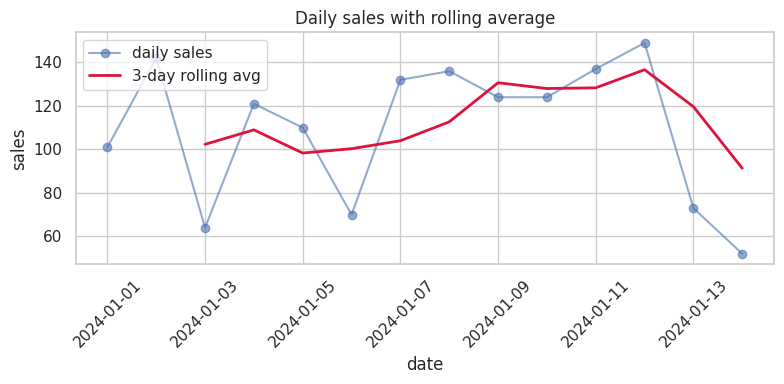

In [19]:
# Visualize raw sales vs the smoothed rolling average
# (a first small taste of Part 3 -- we'll cover matplotlib properly there)
plt.figure(figsize=(8, 4))
plt.plot(ts.index, ts["sales"], marker="o", label="daily sales", alpha=0.6)
plt.plot(ts.index, ts["3day_avg"], color="crimson", linewidth=2, label="3-day rolling avg")
plt.title("Daily sales with rolling average")
plt.xlabel("date"); plt.ylabel("sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### String methods (`.str`) & method chaining
The `.str` accessor gives vectorized string operations — no need to loop over rows.

In [20]:
emails = pd.Series(["Amit.K@mail.com", "sara_j@work.org", "  RAVI@test.com  "])

print("lowercase       :", emails.str.lower().tolist())
print("stripped+lower  :", emails.str.strip().str.lower().tolist())
print("contains 'mail' :", emails.str.contains("mail").tolist())
print("domain (split)  :", emails.str.split("@").str[1].str.strip().tolist())

# Method chaining -- a whole cleaning pipeline in one readable expression
cleaned = (
    df.assign(name_upper=df["name"].str.upper())
      .query("marks >= 80")
      .sort_values("marks", ascending=False)
      .reset_index(drop=True)
)
print("\nchained pipeline result:\n", cleaned)


lowercase       : ['amit.k@mail.com', 'sara_j@work.org', '  ravi@test.com  ']
stripped+lower  : ['amit.k@mail.com', 'sara_j@work.org', 'ravi@test.com']
contains 'mail' : [True, False, False]
domain (split)  : ['mail.com', 'work.org', 'test.com']

chained pipeline result:
     name  age   city  marks  passed grade city_upper name_upper
0  Karan   24  Delhi     95    True     A      DELHI      KARAN
1   Sara   25  Delhi     92    True     A      DELHI       SARA
2   Neha   22   Pune     88    True     B       PUNE       NEHA
3   Amit   21   Pune     85    True     B       PUNE       AMIT
